# Notebook 02 — The Oracles: scoring antibody developability

**Where this sits.** Notebook 01 built a generator that proposes CDRH3 loops. To *optimize* them
with RL we need a differentiable-in-reward signal that says how good each loop is. This notebook
builds three **oracles** — functions that map a sequence to a score in [0,1] — covering distinct
axes of antibody quality.

| How to read this notebook | |
|---|---|
| **Question** | §1 — what makes an antibody "developable"? |
| **Background from zero** | §2 — liabilities, physicochemistry, humanness |
| **Oracle 1: sequence liabilities** | §3 — regex motifs, and why |
| **Oracle 2: physicochemistry** | §4 — charge and hydrophobicity |
| **Oracle 3: humanness** | §5 — a language model likelihood (the deepest one) |
| **Design decision: orthogonality** | §6 — do the three oracles measure different things? |
| **Synthesis** | §7 |


## 1. Question

A generated loop can be perfectly valid and still be a bad drug candidate: it might degrade on the
shelf, aggregate, or trigger an immune response. **Developability** is the umbrella term for "will
this molecule survive manufacturing, storage, and the human body?"

> **Can we capture developability with a small set of cheap, independent oracles that each score a
> CDRH3 in [0,1], so their combination is a meaningful reward?**

**Hypothesis.** Three oracles — chemical liabilities, physicochemistry, and humanness — measure
*different* failure modes, so they should be weakly correlated. If they were redundant (highly
correlated) we would not need three.

## 2. Background from zero

**Developability failure modes, in plain terms:**

- **Chemical liabilities.** Certain amino-acid motifs are chemically unstable. `NG`/`NS`
  deamidate, `DG`/`DS` isomerize, free `M` (methionine) oxidizes, `N[^P][ST]` is an N-glycosylation
  sequon, `DP` fragments. Each is a known manufacturing/stability risk. Fewer motifs = safer.
- **Physicochemistry.** Net **charge** and **hydrophobicity** (GRAVY = Grand Average of
  Hydropathy) control solubility and aggregation. Too charged or too hydrophobic loops aggregate.
- **Humanness.** A therapeutic antibody should look like a *human* antibody, or the patient's
  immune system may attack it (immunogenicity). We measure this with a language model trained on
  human antibodies: how likely is this loop under the human-antibody distribution?

**Design principle: each oracle returns [0,1], 1 = best.** This makes them directly combinable into
a weighted reward (notebook 04) and comparable on the same axis.

## 3. Oracle 1 — sequence liabilities

The simplest oracle: scan the CDRH3 for the known-risky motifs and penalize each hit. Pure
sequence pattern-matching, no model. `score = max(0, 1 - 0.15 * num_hits)`.

In [1]:
# --- Setup: load AbLang (for the humanness oracle) and the oracle module ---
import warnings, os, sys, json, re, itertools
warnings.filterwarnings("ignore")
import numpy as np, torch
import tqdm
_o = tqdm.std.tqdm.__init__
tqdm.std.tqdm.__init__ = lambda self,*a,**k: _o(self,*a,**{**k,"disable":True})

PARENT = ("EVQLVESGGGLVQPGGSLRLSCAASGFNIKEYYMHWVRQAPGKGLEWVGLIDPEQGNTIYDPKFQDRATIS"
          "ADNSKNTAYLQMNSLRAEDTAVYYCARDTAAYFDYWGQGTLVTVS")
INFILL_START = 98; CLOSING = "WGQGTLVTVS"
def extract_cdrh3(seq): return seq[INFILL_START:seq.index(CLOSING)]

# oracles.py is the single source of truth (imported by every notebook + the RL loop) so a scoring
# change propagates everywhere. AbLang2 weights are redirected to a writable cache (package is read-only).
import ablang2, ablang2.load_model as lm
_DEST = os.path.abspath("ablang_weights")
lm.download_model = lambda model_to_use="ablang2-paired": os.path.join(_DEST, f"model-weights-{model_to_use}")
sys.path.insert(0, "src"); import oracles
oracles.ABLANG_MODEL = ablang2.pretrained(model_to_use="ablang2-paired", device="cpu")
print("AbLang2 loaded | liability motifs:", list(oracles.LIABILITY_MOTIFS.keys()))

AbLang2 loaded | liability motifs: ['deamidation_NG', 'deamidation_NS', 'isomerization_DG', 'isomerization_DS', 'oxidation_M', 'nglyc_sequon', 'fragmentation_DP']


In [2]:
# --- Oracle 1: liabilities. Regex-count risky motifs in the CDRH3, penalize each hit. ---
# LIABILITY_MOTIFS maps a name -> a regex. Most are literal 2-mers (NG, DG, ...); the glycosylation
# sequon N[^P][ST] is a real pattern (Asn, any-non-Pro, Ser/Thr). re.findall counts NON-overlapping hits.
LIAB = oracles.LIABILITY_MOTIFS
demo = "DTAAYFDY"  # the parent CDRH3
hits = {name: re.findall(pat, demo) for name, pat in LIAB.items()}
print("parent CDRH3:", demo)
print("motif hits:", {k:v for k,v in hits.items() if v})
print(f"liability score = max(0, 1 - 0.15 * n_hits) = {oracles.liability_oracle(demo):.3f}")
# A loop with a deamidation site scores lower:
print("with NG site 'DTANGFDY':", oracles.liability_oracle("DTANGFDY"))

parent CDRH3: DTAAYFDY
motif hits: {}
liability score = max(0, 1 - 0.15 * n_hits) = 1.000
with NG site 'DTANGFDY': 0.85


## 4. Oracle 2 — physicochemistry

Uses Biopython's `ProteinAnalysis` to compute two biophysical properties of the loop and score how
close each sits to a healthy window: **net charge at pH 7** (window -2 to +2) and **GRAVY
hydrophobicity** (window -1 to 0, i.e. mildly hydrophilic). Each property gets a linear-decay score
outside its window; the oracle averages them.

In [3]:
# --- Oracle 2: physicochemistry via Biopython ProteinAnalysis ---
# charge_at_pH(7.0): net charge of the loop at physiological pH (Henderson-Hasselbalch over ionizable
#   residues). gravy(): mean Kyte-Doolittle hydrophobicity. _range_score linearly decays to 0 outside
#   the healthy window. The two sub-scores are averaged -> [0,1].
from Bio.SeqUtils.ProtParam import ProteinAnalysis
a = ProteinAnalysis(demo)
print(f"parent CDRH3 charge@pH7 = {a.charge_at_pH(7.0):+.2f}  (window {oracles.CHARGE_RANGE})")
print(f"parent CDRH3 GRAVY      = {a.gravy():+.2f}  (window {oracles.GRAVY_RANGE})")
print(f"protparam score = {oracles.protparam_oracle(demo):.3f}")
# A highly charged loop scores lower:
print("charged 'DDDRRKKED':", round(oracles.protparam_oracle("DDDRRKKED"),3))

parent CDRH3 charge@pH7 = -2.24  (window (-2.0, 2.0))
parent CDRH3 GRAVY      = -0.49  (window (-1.0, 0.0))
protparam score = 0.970
charged 'DDDRRKKED': 0.5


## 5. Oracle 3 — humanness (the deepest oracle)

This is the one an interviewer will drill into, because it is a real language-model likelihood.
**AbLang2** is an antibody language model. We feed it the full heavy chain and it returns, at every
position, a probability distribution over amino acids. Humanness = how probable the *actual*
residues in the CDRH3 are under the model.

**The mechanism, precisely (this is the interview answer):**
- `ABLANG_MODEL([[heavy, ""]], mode="likelihood")` returns a per-position **logits/likelihood
  matrix** of shape `(L_tokens, 26)` — 26 = the AbLang vocabulary (20 AAs + special tokens).
- We apply a **softmax over the vocabulary axis** (last axis) to turn each row into a probability
  distribution over amino acids at that position.
- There is a **`START_TOKEN_OFFSET = 1`**: AbLang prepends a start token, so sequence position
  `pos` maps to matrix row `pos + 1`. Getting this offset wrong silently shifts every score by one
  residue.
- For each CDRH3 position we index `probs[pos + 1, token_id_of_actual_residue]` — the model's
  probability of the residue that is actually there — and **average over the CDRH3 window only**
  (positions 98 to the closing motif). We do NOT score the framework, which is constant.

In [4]:
# --- Oracle 3: humanness = mean AbLang likelihood of the ACTUAL CDRH3 residues ---
# Walk through the mechanism explicitly so the indexing is auditable.
seq = PARENT
per_pos = oracles.ABLANG_MODEL([[seq, ""]], mode="likelihood")   # -> array, shape (L_tokens, vocab=26)
print("AbLang per-position matrix shape:", np.array(per_pos[0]).shape, "(rows=positions, cols=vocab)")

probs = oracles._softmax(per_pos[0])                             # softmax over dim=-1 (VOCAB axis)
s, e = INFILL_START, seq.index(CLOSING)
tokmap = oracles.ABLANG_MODEL.tokenizer.aa_to_token              # amino-acid -> vocab column index
# For each CDRH3 residue: look up its probability at row (pos + START_TOKEN_OFFSET), its own column.
per_residue = [(seq[pos], float(probs[pos + oracles.START_TOKEN_OFFSET, tokmap[seq[pos]]]))
               for pos in range(s, e)]
print("per-residue P(actual):", [(aa, round(p,2)) for aa,p in per_residue])
print(f"humanness = mean = {oracles.humanness_oracle(seq):.3f}   (START_TOKEN_OFFSET={oracles.START_TOKEN_OFFSET})")

AbLang per-position matrix shape: (119, 26) (rows=positions, cols=vocab)
per-residue P(actual): [('D', 0.62), ('T', 0.74), ('A', 0.71), ('A', 0.58), ('Y', 0.58), ('F', 0.5), ('D', 0.91), ('Y', 0.76)]
humanness = mean = 0.676   (START_TOKEN_OFFSET=1)


## 6. Design decision — are three oracles justified? (orthogonality)

**The question behind the design.** If the three oracles were highly correlated, they would be
measuring the same thing and we would be double-counting. Combining them into a reward is only
justified if they carry **independent** signal. We test this by scoring a pool of 80 generated
loops with all three and computing the correlation matrix.

In [5]:
# --- Score 80 loops with all three oracles; measure spread and correlation ---
def valid_cdrh3(full):
    if CLOSING not in full: return False
    c = extract_cdrh3(full); return 4 <= len(c) <= 25 and set(c) <= set("ACDEFGHIKLMNPQRSTVWY")

sc = json.load(open("nb02_scores.json"))          # cached pool + scores (generated once, deterministic)
liab, phys, human = np.array(sc["liability"]), np.array(sc["protparam"]), np.array(sc["humanness"])
M = np.array([liab, phys, human]); corr = np.corrcoef(M)
for name, x in [("liability", liab), ("protparam", phys), ("humanness", human)]:
    print(f"{name:10s} mean {x.mean():.3f}  std {x.std():.3f}  range {x.min():.2f}-{x.max():.2f}")
print(f"\nmax |off-diagonal correlation| = {np.max(np.abs(corr-np.eye(3))):.3f}  (near 0 => independent)")

liability  mean 0.921  std 0.111  range 0.55-1.00
protparam  mean 0.884  std 0.160  range 0.35-1.00
humanness  mean 0.646  std 0.064  range 0.50-0.78

max |off-diagonal correlation| = 0.141  (near 0 => independent)


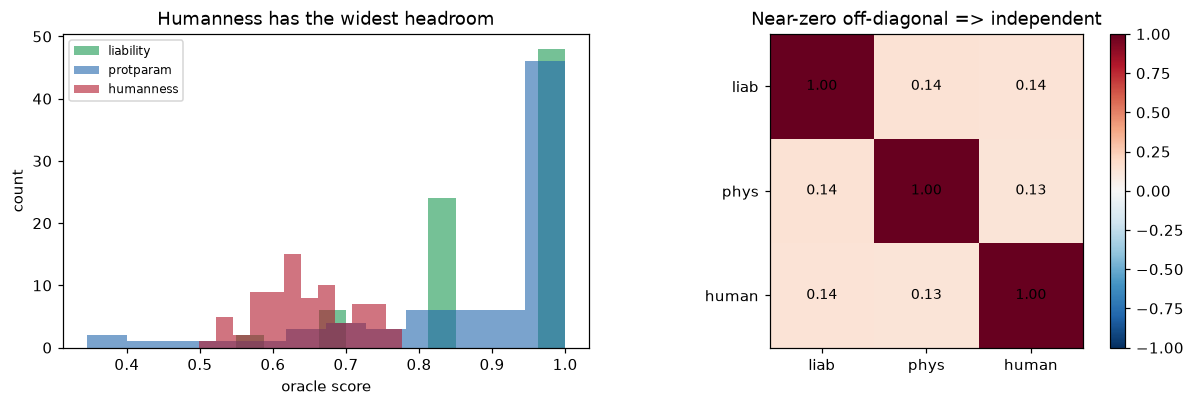

In [6]:
# --- Visualize: score distributions + correlation heatmap ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].hist(liab, bins=12, alpha=0.6, color="#1a9850", label="liability")
ax[0].hist(phys, bins=12, alpha=0.6, color="#2166ac", label="protparam")
ax[0].hist(human, bins=12, alpha=0.6, color="#b2182b", label="humanness")
ax[0].set_xlabel("oracle score"); ax[0].set_ylabel("count")
ax[0].set_title("Humanness has the widest headroom"); ax[0].legend(fontsize=8)
im = ax[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1].set_xticks(range(3)); ax[1].set_yticks(range(3))
lbl = ["liab","phys","human"]; ax[1].set_xticklabels(lbl); ax[1].set_yticklabels(lbl)
for i in range(3):
    for j in range(3): ax[1].text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax[1].set_title("Near-zero off-diagonal => independent"); fig.colorbar(im, ax=ax[1], fraction=0.046)
fig.tight_layout(); fig.savefig("nb02_oracles.png", dpi=120, bbox_inches="tight"); plt.show()

**Decision.** The off-diagonal correlations are all below 0.15 — the three oracles are
effectively **independent**. This justifies combining them: each contributes signal the others do
not. It also tells us something for the reward design (notebook 04): **humanness has the widest
spread** (range 0.50-0.78, std 0.06) while liability and physicochemistry are near-saturated
(means 0.92, 0.88). Humanness is where an optimizer has the most room to move, which is why it gets
the largest reward weight (0.50).

## 7. Synthesis

| Oracle | Mechanism | What it catches | Spread |
|---|---|---|---|
| Liability | regex motif count | chemical instability | saturated (mean 0.92) |
| Physicochemistry | Biopython charge + GRAVY | aggregation/solubility | saturated (mean 0.88) |
| Humanness | AbLang2 per-position likelihood | immunogenicity | wide (mean 0.65) |

**Independence confirmed** (max correlation 0.14): the three measure different failure modes, so
combining them is meaningful, not redundant.

**What this sets up.** Notebook 04 combines these into a single reward `S(x)` (weights 0.50 / 0.30
/ 0.20, humanness heaviest because it has the most headroom). Notebook 03 adds a *structural*
oracle (TAP). Notebook 06 adds a *binding* oracle. Together they form the multimodal evaluator the
RL loop optimizes against.

---
*All three oracles are cheap (regex + Biopython + one AbLang forward pass), so they are fast enough
to call inside the RL loop's inner batch.*